<a href="https://colab.research.google.com/github/lithikaneelakandan56-ctrl/ml_practice/blob/main/ML/day05_logistic_regression_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Build a classification model that predicts whether a breast tumour is mal
#Logistic Regression Classification

In [9]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)
df["target"]=y
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(data.target_names)
print(y.value_counts())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [10]:
# data preprocessing
print(df.isnull().sum())
print(df.duplicated().sum())
print(y.value_counts())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64
0
1    357
0    212
Name: count, dtype: int64


In [11]:
# splitting the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


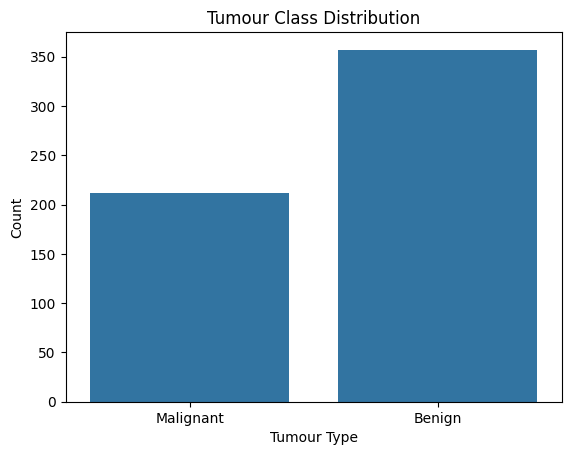

In [12]:
#eda
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x=y.map({0: "Malignant", 1: "Benign"}))
plt.title("Tumour Class Distribution")
plt.xlabel("Tumour Type")
plt.ylabel("Count")
plt.show()

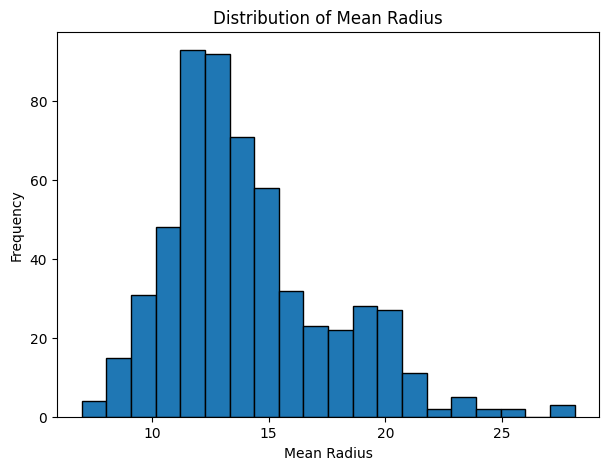

In [13]:
#feature distribution-histogram
plt.figure(figsize=(7, 5))
plt.hist(X["mean radius"], bins=20, edgecolor="black")
plt.title("Distribution of Mean Radius")
plt.xlabel("Mean Radius")
plt.ylabel("Frequency")
plt.show()

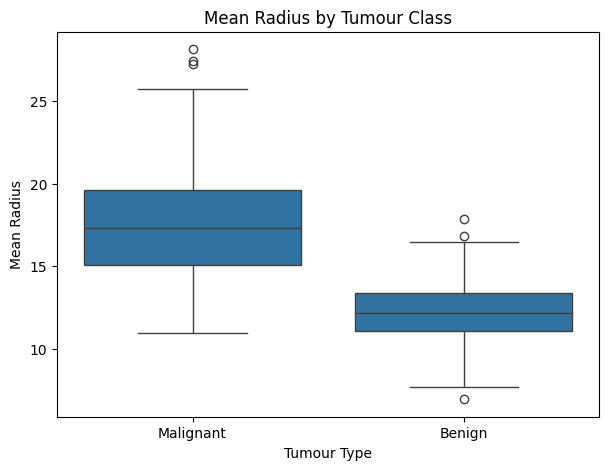

In [14]:
plt.figure(figsize=(7, 5))
sns.boxplot(x=y.map({0: "Malignant", 1: "Benign"}),y=X["mean radius"])
plt.title("Mean Radius by Tumour Class")
plt.xlabel("Tumour Type")
plt.ylabel("Mean Radius")
plt.show()

In [15]:
# building the lr
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
model = Pipeline([("scaler", StandardScaler()),("classifier", LogisticRegression(max_iter=1000))])
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression(max_iter=1000))])

In [16]:
# evaluate the model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

[[41  1]
 [ 1 71]]


In [17]:
probabilities = model.predict_proba(X_test)
print(probabilities[:10])
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

[[9.99999941e-01 5.88824186e-08]
 [1.13351672e-05 9.99988665e-01]
 [9.93589175e-01 6.41082462e-03]
 [4.66491463e-01 5.33508537e-01]
 [9.99999999e-01 6.52500097e-10]
 [7.83960163e-03 9.92160398e-01]
 [1.71746799e-05 9.99982825e-01]
 [9.99999436e-01 5.63527494e-07]
 [9.99945684e-01 5.43163692e-05]
 [1.00000000e+00 8.04184941e-11]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



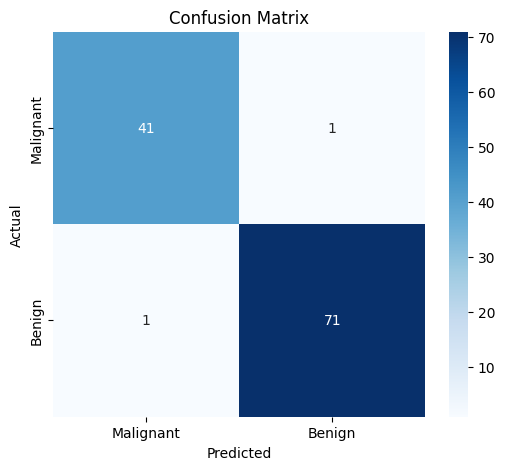

In [18]:
#visualization
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
# prediction
sample = X_test.iloc[[0]]
prediction = model.predict(sample)
if prediction[0] == 0:
    print("Predicted Class: Malignant")
else:
    print("Predicted Class: Benign")

Predicted Class: Malignant
